# Dataset Curation 

some of our dft calculations could have gone wrong. The way to filter this is through the E-V curves for each sample. 

# 
- input : non curated bs
- output: curated bs regarding ev curves

TODO: bopio and bopcal needed for featurizer ! separate package for bopfox ?

## check ev-curves for goodness

In [1]:
import sys
#sys.path.insert(0,'/home/storage/fortimtb/DatasetsML/Tools/')
sys.path.insert(0,'/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/')
dataset = 'Fe-Mo'  #'Cr-Co-W'
atoms = dataset.split('-')
from Tools.DatasetTools.EVCurvesTools import *
from BopFoxFeaturizer.Featurizer import Featurizer
import pickle
import os

In [2]:
plt.rc('figure', figsize=(12,8))
plt.rc('font', size=22)

In [3]:
def get_key_for_curves(EVC: pd.core.series.Series, key='str') -> pd.core.series.Series:
    r2 = {}
    for index, data in EVC.items():
        r2[index]={}
        for params, curve in data.items():
            r2[index].update({params: curve[key]})
    return pd.Series(r2)
    

In [4]:
PBS = pd.read_pickle(os.path.join(dataset, 'ParsedBriefsummary.pkl'))

## Investigate ev-curves

In [5]:
fittedcurvesloc = os.path.join(dataset, 'evcurvesfitted.json')
evcurvesloc = os.path.join(dataset,'evcurves.json' )
goodnessloc = os.path.join(dataset, 'goodness.json')
if not os.path.exists(fittedcurvesloc):
    if not os.path.exists(evcurvesloc):
        EV = Evcurves(Indexes = PBS.index, atoms=['Fe','Mo'], dataset = dataset)#, search_str='**/volume_relaxed/**/volume-energy.dat')
        EV.load_evcurves( deltaks = PBS['deltak'], encuts = PBS['encut'])
        EVcurves = EV.evcurves
        EVcurves.to_json(evcurvesloc)
    else:
        EVcurves = pd.read_json(evcurvesloc, typ='series')
    goodness, fiteos, r2  = get_goodness(EVcurves)
    if goodness.map(lambda g: False in g.values()).all():
        goodness = invert_goodness(goodness)
    Goodness = pd.Series(goodness)
    Fits = pd.Series(fiteos)
    R2 = pd.Series(r2)
    for index, data in EVcurves.items():
        for key, evcurve in data.items():
            data[key].update({'r2': R2[index][key], 'fit': Fits[index][key], 'IsGood': Goodness[index][key]})
    EVcurves.to_json(fittedcurvesloc)
else:
    EVcurves = pd.read_json(fittedcurvesloc, typ='series')
    R2 = get_key_for_curves(EVcurves, 'r2')
    Goodness = get_key_for_curves(EVcurves, 'IsGood')
    Fits = get_key_for_curves(EVcurves, 'fit')

In [6]:
indexofgoodsamples = []
for index, data in EVcurves.items():
    for params, evcurve in data.items():
        if  evcurve['IsGood']:
            indexofgoodsamples.append(index)
indexofgoodsamples = pd.Index(indexofgoodsamples)

In [7]:
GoodBS = PBS.loc[indexofgoodsamples]
BadBS = PBS.loc[PBS.index.difference(indexofgoodsamples)]

In [8]:
GoodBS = GoodBS[~GoodBS.index.str.contains('sigma-BABBB.FM|sigma-AABBB.FM|mu-BBBBA.FM')]

## Remove extra magnetic sampling

First feature to remove from this dataset is the list of samples used form ferrimagnetic phase sampling. This subset is not in the current interest and might bring problems so we remove from datastet.

In [9]:
GoodBS = GoodBS.loc[~GoodBS.index.str.contains('\..*[UD]+$') ]

## Obtain some info from indexes

In [10]:
Features = Featurizer(GoodBS)

In [11]:
GoodBS

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,B0,V0,atom_A,atom_B,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv,EF
Fe_pv8Mo_sv22.sigma-BBABB.FM,bulk sigma-BBABB.FM,14.954763 A,-10.004507,224.285410 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,224.285410,14.954763,Fe_pv,Mo_sv,8,22,30,0.266667,0.733333,0.215355
Fe_pv10Mo_sv20.sigma-ABBAB.FM,bulk sigma-ABBAB.FM,14.130625 A,-10.006896,237.907324 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,237.907324,14.130625,Fe_pv,Mo_sv,10,20,30,0.333333,0.666667,0.034369
Fe_pv4Mo_sv20.C36-ABBBB.FM,bulk C36-ABBBB.FM,16.270923 A,-10.007837,204.470374 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,204.470374,16.270923,Fe_pv,Mo_sv,4,20,24,0.166667,0.833333,0.479921
Fe_pv3Mo_sv10.mu-ABBBA.FM,bulk mu-ABBBA.FM,15.378254 A,-10.008565,402.123952 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,402.123952,15.378254,Fe_pv,Mo_sv,3,10,13,0.230769,0.769231,0.307465
Fe_pv5Mo_sv24.chi-AABB.FM,bulk chi-AABB.FM,15.751001 A,-10.015010,216.183583 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,216.183583,15.751001,Fe_pv,Mo_sv,5,24,29,0.172414,0.827586,0.457352
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fe_pv3Mo_sv10.mu-ABBBA.NM,bulk mu-ABBBA,15.125643 A,-9.973264,240.020984 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,240.020984,15.125643,Fe_pv,Mo_sv,3,10,13,0.230769,0.769231,0.326354
Fe_pv8Mo_sv22.sigma-BBABB.NM,bulk sigma-BBABB,14.698886 A,-9.976143,247.238692 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,247.238692,14.698886,Fe_pv,Mo_sv,8,22,30,0.266667,0.733333,0.224750
Fe_pv1Mo_sv3.L12-AB3.FM,bulk L12-AB3.FM,14.806728 A,-9.986411,223.435464 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,223.435464,14.806728,Fe_pv,Mo_sv,1,3,4,0.250000,0.750000,0.278101
Fe_pv8Mo_sv22.sigma-BBBBA.FM,bulk sigma-BBBBA.FM,15.095159 A,-9.991080,207.683558 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,207.683558,15.095159,Fe_pv,Mo_sv,8,22,30,0.266667,0.733333,0.228782


## translate structures to their bases

# TODo this sould be in tools, as a phase cleaner

In [12]:
from BopFoxFeaturizer.struct_db import struct_db
#struct_db = SourceFileLoader('struct_db','BopFoxFeaturizer/struct_db.py').load_module().struct_db
strucdic = struct_db().strucstrings

Target_Class = pd.Series(
    GoodBS.index.str.split('.').map(lambda l: l[1]).map(lambda s: s.split('-')[0]),
    index=GoodBS.index
)
Target_Class[Target_Class.map(lambda s: s in strucdic['list.hcp'])]='hcp'
Target_Class[Target_Class.map(lambda s: s in strucdic['list.fcc'])]='fcc'
Target_Class[Target_Class.map(lambda s: s in strucdic['list.bcc'])]='bcc'
Target_Class[Features.Struc == 'hcp'] = 'hcp'
Target_Class[Features.Struc == 'bcc'] = 'bcc'
Target_Class[Features.Struc == 'fcc'] = 'fcc'
Target_Class[Features.Struc.str.contains('SQS-fcc')] = 'fcc'
Target_Class[Features.Struc.str.contains('SQS-L12')] = 'fcc'
Target_Class[Features.Struc.str.contains('sigma_')] = 'sigma'

Target_Class[    
    Target_Class.str.contains('Al42W') |\
    Target_Class.str.contains('Al9Co2') |\
    Target_Class.str.contains('Al5W') |\
    Target_Class.str.contains('Al12W') |\
    Target_Class.str.contains('Al4W') |\
    Target_Class.str.contains('Al5Co2')
] = 'others'

In [13]:
Target_Class

Fe_pv8Mo_sv22.sigma-BBABB.FM     sigma
Fe_pv10Mo_sv20.sigma-ABBAB.FM    sigma
Fe_pv4Mo_sv20.C36-ABBBB.FM         C36
Fe_pv3Mo_sv10.mu-ABBBA.FM           mu
Fe_pv5Mo_sv24.chi-AABB.FM          chi
                                 ...  
Fe_pv3Mo_sv10.mu-ABBBA.NM           mu
Fe_pv8Mo_sv22.sigma-BBABB.NM     sigma
Fe_pv1Mo_sv3.L12-AB3.FM            fcc
Fe_pv8Mo_sv22.sigma-BBBBA.FM     sigma
Fe_pv10Mo_sv20.sigma-ABBAB.NM    sigma
Length: 289, dtype: object

In [14]:
Target_Class.to_pickle('Fe-Mo/Descriptors/ClassLabels.pkl')

In [15]:
GoodBS['Phase'] = Target_Class

In [16]:
GoodBS.describe()

,E0,nelem,B0,V0,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv,EF
count,289.000000,289.000000,289.000000,289.000000,289.000000,289.000000,289.000000,289.000000,289.000000,289.000000
mean,-9.331384,1.858131,199.873474,13.659237,11.854671,9.259516,21.114187,0.498980,0.501020,0.247043
std,0.716599,0.349520,422.311196,1.630018,9.200297,7.679233,11.135097,0.279704,0.279704,0.164601
min,-10.934283,1.000000,-6867.530562,8.318826,1.000000,0.000000,1.000000,0.000000,0.000000,-0.042122
25%,-9.897544,2.000000,207.419971,12.475250,5.000000,3.000000,13.000000,0.307692,0.307692,0.111405
50%,-9.319758,2.000000,237.621056,13.683784,10.000000,8.000000,24.000000,0.500000,0.500000,0.228632
75%,-8.851097,2.000000,257.697239,14.876555,16.000000,14.000000,30.000000,0.692308,0.692308,0.363569
max,-7.780040,2.000000,420.901429,17.320677,56.000000,44.000000,56.000000,1.000000,1.000000,0.721511


# some E-V curves, good and bad

In [17]:
sample_bad = EVcurves[BadBS.index].dropna().sample(n=min(5, BadBS.shape[0]))

In [18]:
sample_bad

Series([], dtype: object)

In [19]:
plt.rc('font', size=22)
plt.rc('figure', figsize=(12,8))

In [20]:
sample_bad_r2 = R2[sample_bad.index]

In [21]:
sample_bad_fit = Fits[sample_bad.index]

In [22]:
figurecollection, axcollection  = plot_curves(sample_bad, sample_bad_fit, sample_bad_r2)

In [23]:
sample_good = EVcurves[GoodBS.index].dropna().sample(n=5)

In [24]:
sample_good

Fe_pv3Mo_sv1.D03-A3B.NM      {'dk': {'evcurve': {}, 'ev_fit_results': {}, '...
Fe_pv5Mo_sv8.mu-ABABA.FM     {'dk': {'evcurve': {}, 'ev_fit_results': {}, '...
Fe_pv10Mo_sv3.mu-BABAA.NM    {'dk': {'evcurve': {}, 'ev_fit_results': {}, '...
Fe_pv4Mo_sv9.mu-BBAAB.NM     {'dk': {'evcurve': {}, 'ev_fit_results': {}, '...
Mo_sv53.R.NM                 {'dk': {'evcurve': {}, 'ev_fit_results': {}, '...
dtype: object

In [25]:
Goodness[sample_good.index]

Fe_pv3Mo_sv1.D03-A3B.NM      {'dk': True}
Fe_pv5Mo_sv8.mu-ABABA.FM     {'dk': True}
Fe_pv10Mo_sv3.mu-BABAA.NM    {'dk': True}
Fe_pv4Mo_sv9.mu-BBAAB.NM     {'dk': True}
Mo_sv53.R.NM                 {'dk': True}
dtype: object

In [26]:
sample_good_r2 = R2[sample_good.index]

In [27]:
sample_good_fit = Fits[sample_good.index]

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


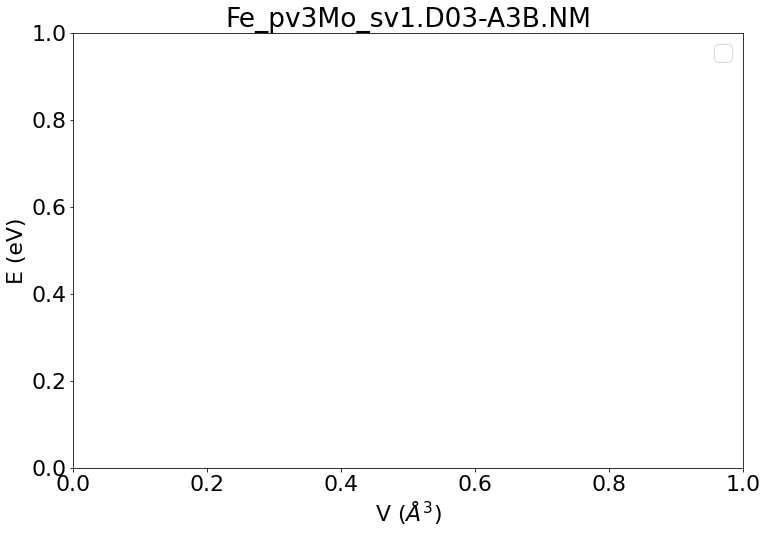

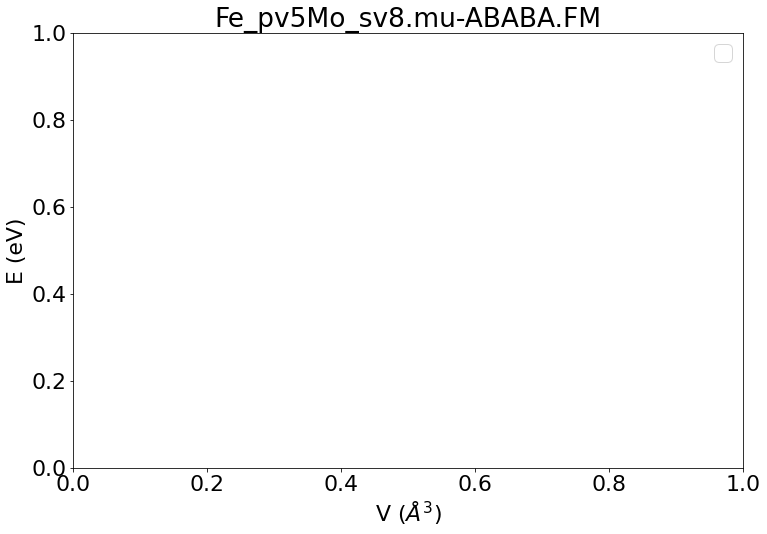

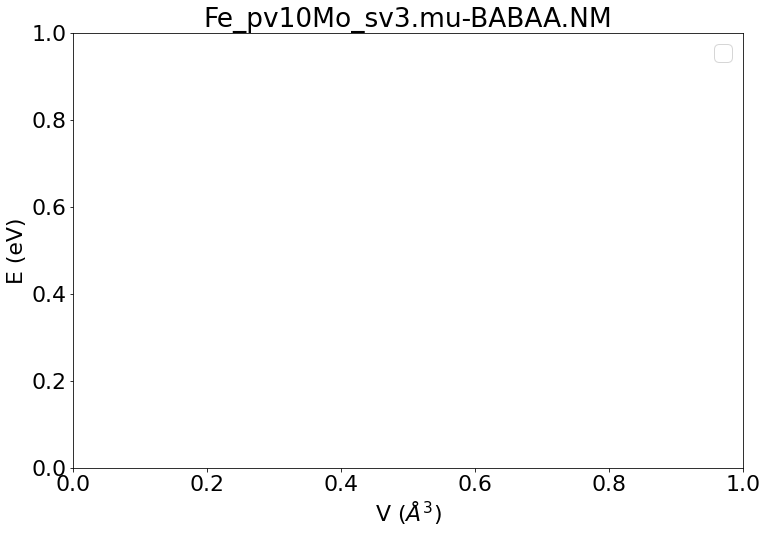

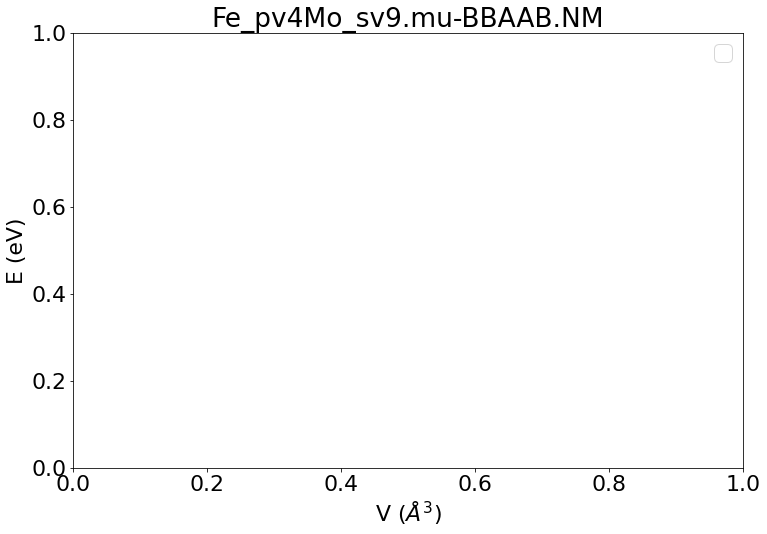

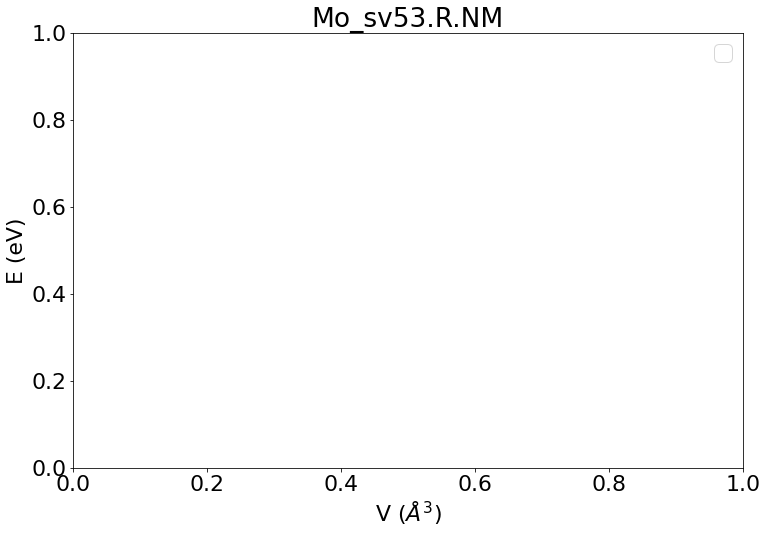

In [28]:
figurecollection, axcollection  = plot_curves(sample_good, sample_good_fit, sample_good_r2)

still high and low B0s

<AxesSubplot:>

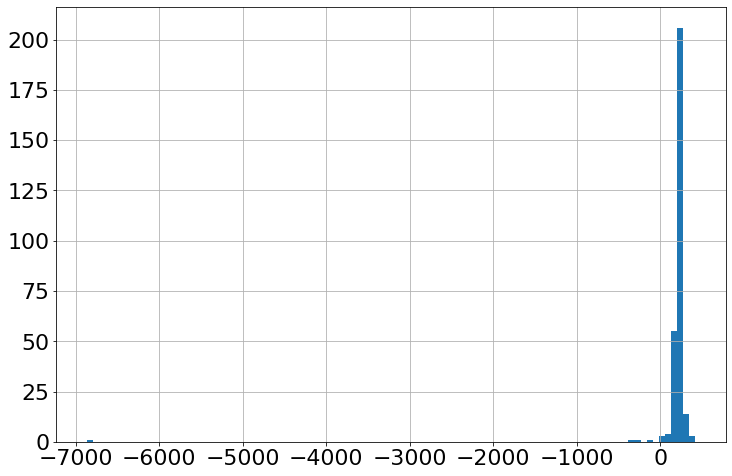

In [29]:
GoodBS.B0.hist(bins=100)

In [30]:
sample_max_B0 = GoodBS[GoodBS.nelem==1].B0.idxmax()

In [31]:
sample_max_B0

'Fe_pv2.hcp.NM'

In [32]:
sample_min_B0 = GoodBS[GoodBS.nelem==1].B0.idxmin()

In [33]:
sample_min_B0

'Fe_pv8.A15.FM'

In [34]:
GoodBS.B0[sample_min_B0]

91.497861

In [35]:
selection = ((GoodBS.B0>GoodBS.B0[sample_max_B0]) | (GoodBS.B0<0.90*GoodBS.B0[sample_min_B0]))

In [36]:
selection_stricter = ((GoodBS.B0>GoodBS.B0[sample_max_B0]) | (GoodBS.B0<0.90*GoodBS.B0[sample_min_B0]) |
                     R2[sample_max_B0] > 0.998)

In [37]:
selection_stricter

Fe_pv8Mo_sv22.sigma-BBABB.FM     True
Fe_pv10Mo_sv20.sigma-ABBAB.FM    True
Fe_pv4Mo_sv20.C36-ABBBB.FM       True
Fe_pv3Mo_sv10.mu-ABBBA.FM        True
Fe_pv5Mo_sv24.chi-AABB.FM        True
                                 ... 
Fe_pv3Mo_sv10.mu-ABBBA.NM        True
Fe_pv8Mo_sv22.sigma-BBABB.NM     True
Fe_pv1Mo_sv3.L12-AB3.FM          True
Fe_pv8Mo_sv22.sigma-BBBBA.FM     True
Fe_pv10Mo_sv20.sigma-ABBAB.NM    True
Name: B0, Length: 289, dtype: bool

In [38]:
samples_high_b0 = GoodBS[selection].index

In [39]:
curve_high_b0 = EVcurves[samples_high_b0]

In [40]:
r2_high_b0 = R2[samples_high_b0]

In [41]:
fits_high_b0 = Fits[samples_high_b0]

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that 

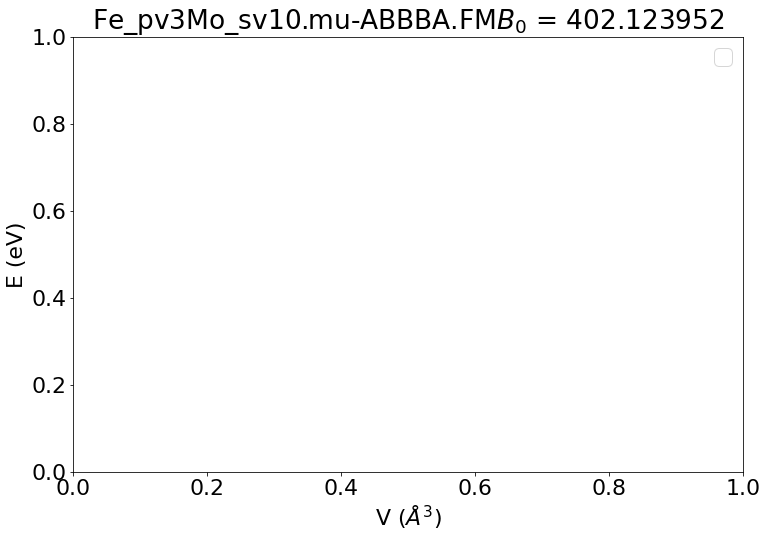

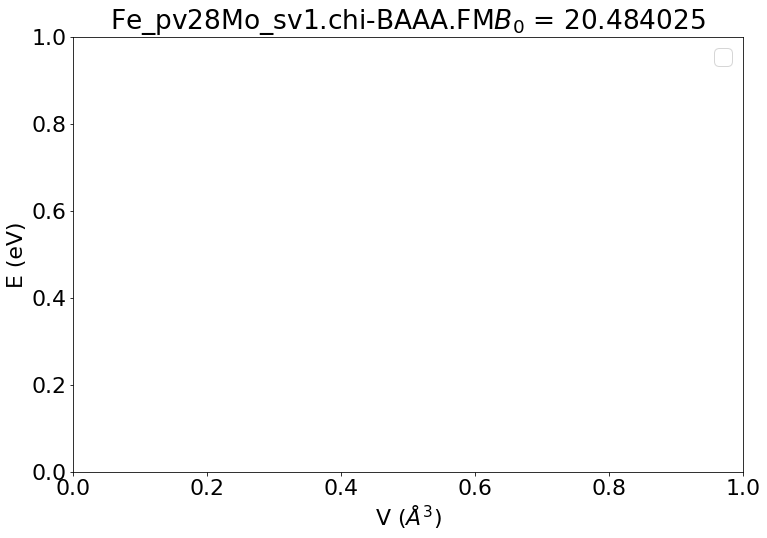

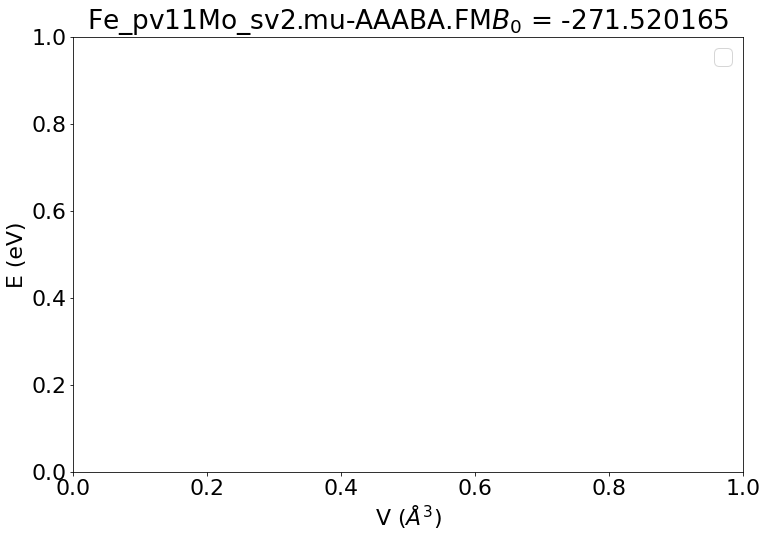

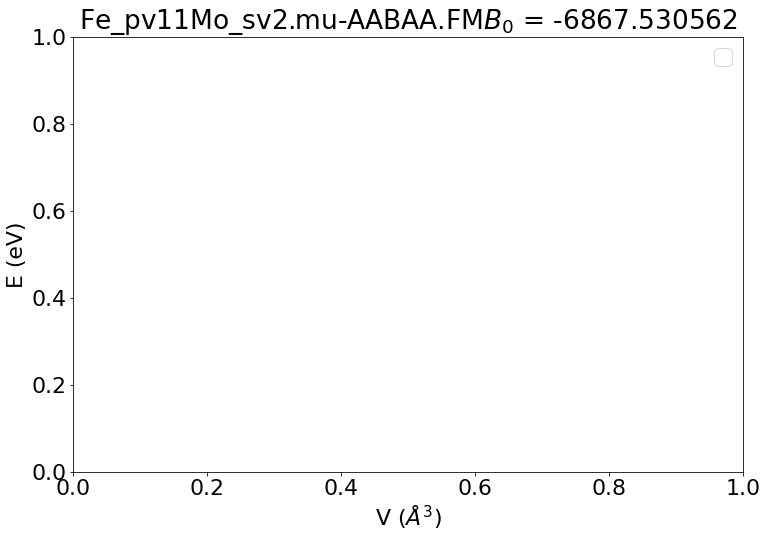

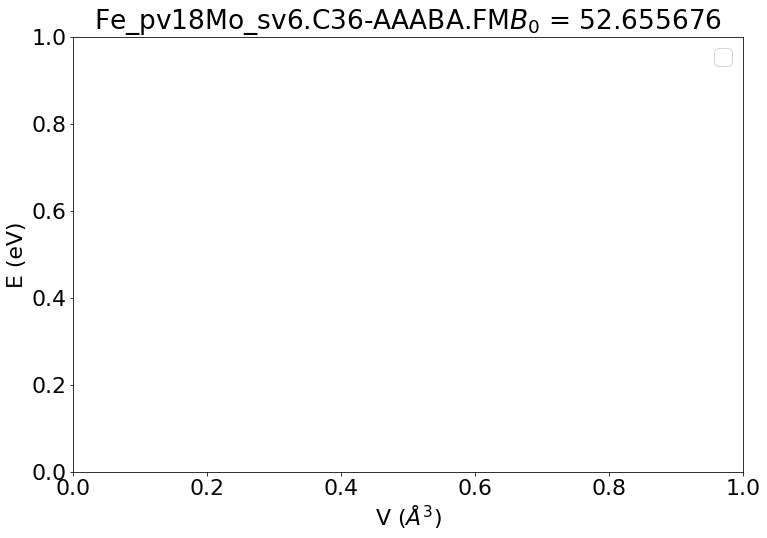

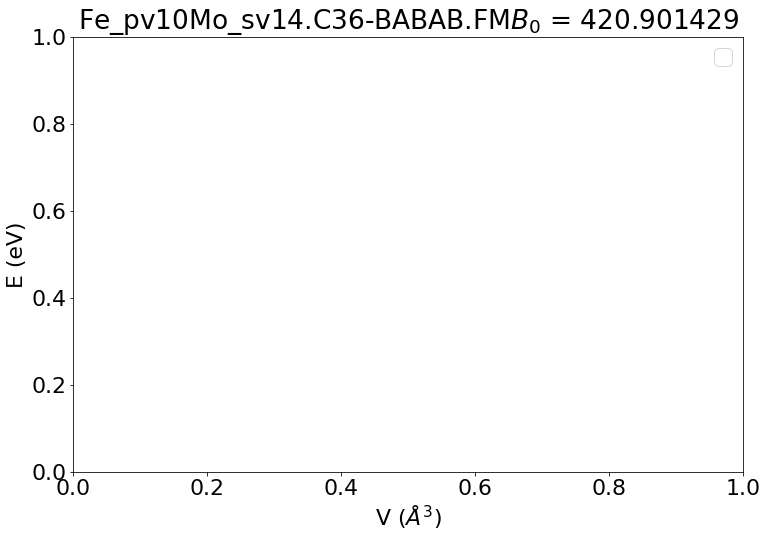

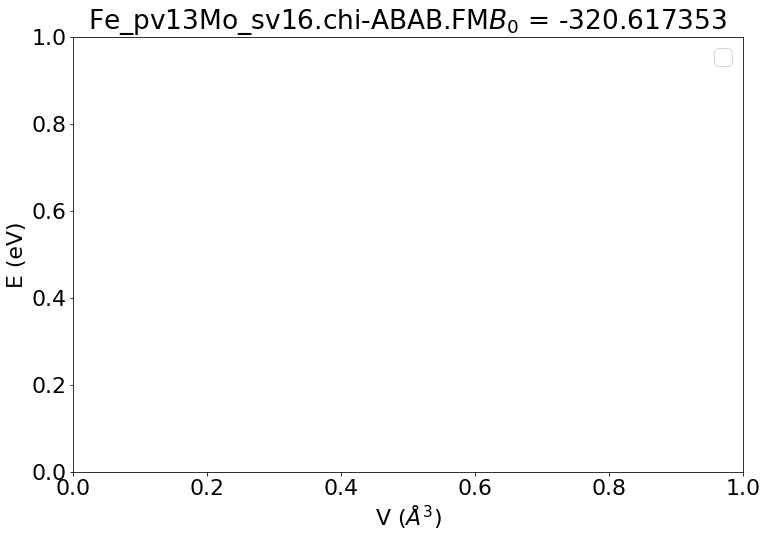

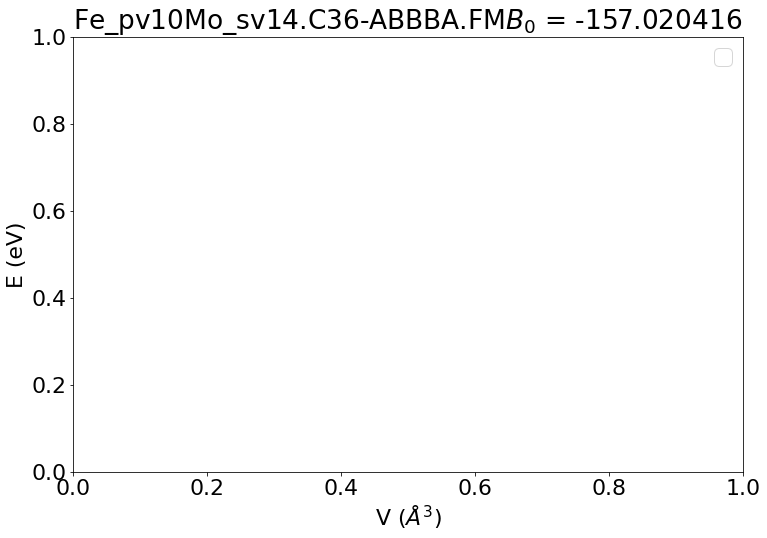

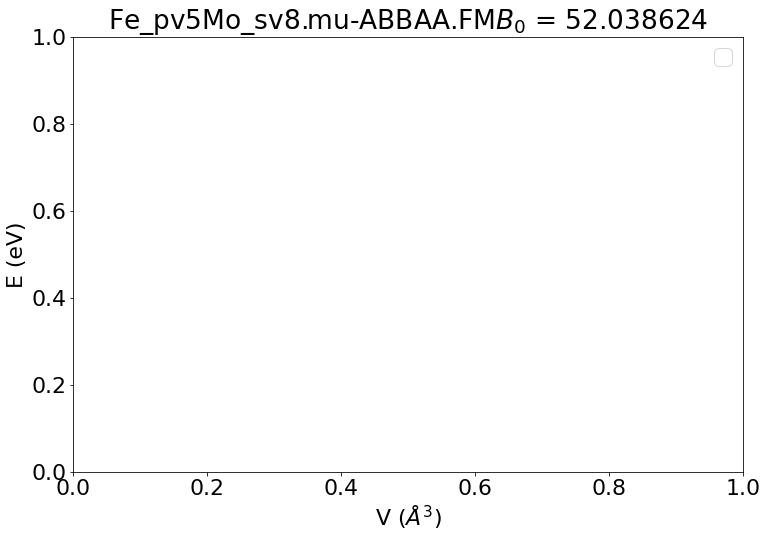

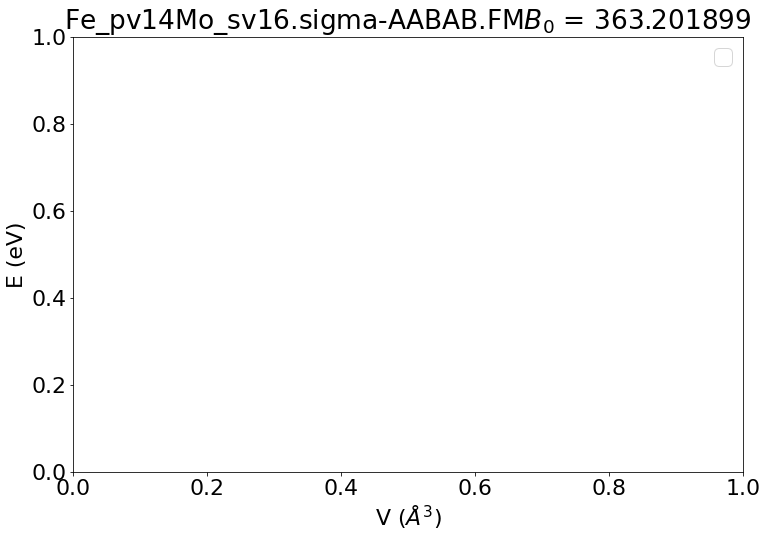

In [42]:
figurecollection, axcollection  = plot_curves(curve_high_b0, fits_high_b0, r2_high_b0)
for ax, index  in zip(axcollection, samples_high_b0):
    title=ax.get_title()
    title += f'$B_0$ = {GoodBS.B0[index]}'
    ax.set_title(title)

In [43]:
GoodBS.drop(index=samples_high_b0, inplace=True)

In [44]:
samples_high_b0

Index(['Fe_pv3Mo_sv10.mu-ABBBA.FM', 'Fe_pv28Mo_sv1.chi-BAAA.FM',
       'Fe_pv11Mo_sv2.mu-AAABA.FM', 'Fe_pv11Mo_sv2.mu-AABAA.FM',
       'Fe_pv18Mo_sv6.C36-AAABA.FM', 'Fe_pv10Mo_sv14.C36-BABAB.FM',
       'Fe_pv13Mo_sv16.chi-ABAB.FM', 'Fe_pv10Mo_sv14.C36-ABBBA.FM',
       'Fe_pv5Mo_sv8.mu-ABBAA.FM', 'Fe_pv14Mo_sv16.sigma-AABAB.FM'],
      dtype='object')

# Save for later use 

In [45]:
curatedbs = os.path.join(dataset,'CuratedParsedBriefSummary.pkl')
GoodBS.to_pickle(curatedbs)

<AxesSubplot:>

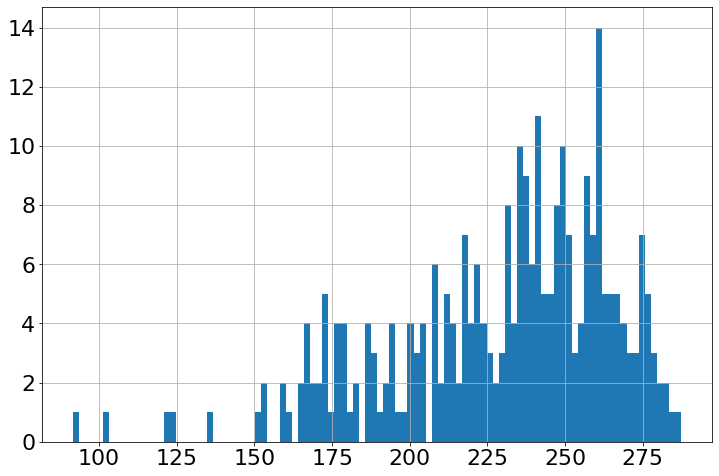

In [46]:
GoodBS.B0.hist(bins=100)